In [2]:
import pandas as pd
import numpy as np
import re

# =========================
# LOAD RAW DATA
# =========================
df = pd.read_csv("../data/raw/development.csv")

df["article"] = df["article"].fillna("").astype(str)

# =========================
# HREF COUNT
# =========================
href_pattern = re.compile(r"<a\s+[^>]*href=", re.IGNORECASE)

df["n_href"] = df["article"].apply(
    lambda x: len(href_pattern.findall(x))
)

# Sanity
print(df["n_href"].describe())


count    79997.000000
mean         0.240397
std          0.861198
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         55.000000
Name: n_href, dtype: float64


In [3]:
label_map = {
    0: "International",
    1: "Business",
    2: "Technology",
    3: "Entertainment",
    4: "Sports",
    5: "General",
    6: "Health"
}

df["label_name"] = df["label"].map(label_map)

href_stats = (
    df.groupby("label_name")["n_href"]
      .agg(["mean", "median", "std", "max", "count"])
      .sort_values("mean", ascending=False)
)

print(href_stats)


                   mean  median       std  max  count
label_name                                           
Technology     0.593047     0.0  1.598320   55  11161
International  0.218078     0.0  0.568878   12  23542
General        0.201486     0.0  0.859502    6  13053
Entertainment  0.183021     0.0  0.893699   29   9977
Business       0.161881     0.0  0.466962    5  10588
Sports         0.125379     0.0  0.363411    4   8574
Health         0.075113     0.0  0.374751    4   3102


In [4]:
href_presence = (
    df.assign(has_href=df["n_href"] > 0)
      .groupby("label_name")["has_href"]
      .mean()
      .sort_values(ascending=False)
)

print(href_presence * 100)


label_name
Technology       18.484007
International    18.273724
Business         13.864753
Sports           11.978073
Entertainment    11.817180
General          10.250517
Health            5.705996
Name: has_href, dtype: float64


In [7]:
import pandas as pd
import numpy as np
import re
import html

from bs4 import BeautifulSoup

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
	f1_score,
	recall_score,
	confusion_matrix,
	classification_report
)

In [8]:
from bs4 import BeautifulSoup
import html
import re

def clean_article_soft(raw):
	# parse HTML
	soup = BeautifulSoup(raw, "html.parser")

	# rimuovi solo elementi non visibili
	for tag in soup(["script", "style", "noscript"]):
		tag.decompose()

	# mantieni anchor text dei link
	for a in soup.find_all("a"):
		a.replace_with(" " + a.get_text(" ", strip=True) + " ")

	# rimuovi immagini (zero testo utile)
	for img in soup.find_all("img"):
		img.decompose()

	# estrai testo visibile
	text = soup.get_text(" ")

	# decode entità HTML
	text = html.unescape(text)

	# FIX encoding sporco (questo è IL punto chiave)
	text = (
		text.encode("latin1", errors="ignore")
		    .decode("utf-8", errors="ignore")
	)

	# normalizza spazi
	text = re.sub(r"\s+", " ", text).strip()

	return text


In [9]:
# =========================
# LOAD DATA
# =========================
df = pd.read_csv("../data/processed/v3/development_v3.csv")

df["article"] = df["article"].fillna("").astype(str)
df["title"]   = df["title"].fillna("").astype(str)
df["source"]  = df["source"].fillna("unknown").astype(str)

# >>> NUOVO STEP <<<
df["article_clean"] = df["article"].apply(clean_article_soft)

X = df.drop(columns=["label"])
y = df["label"]


C:\Users\msist\AppData\Local\Temp\ipykernel_40876\3716950427.py:7: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(raw, "html.parser")


In [10]:

# =========================================
# PREPROCESSOR (IDENTICO AL TUO)
# =========================================
preprocess = ColumnTransformer(
	transformers=[
		# ARTICLE (CLEANED)
		("article", TfidfVectorizer(
			max_features=120_000,
			ngram_range=(1,2),
			min_df=3,
			max_df=0.9,
			sublinear_tf=True,
			stop_words="english"
		), "article_clean"),

		# TITLE
		("title", TfidfVectorizer(
			max_features=30_000,
			ngram_range=(1,2),
			min_df=2,
			max_df=0.95,
			sublinear_tf=True,
			stop_words="english"
		), "title"),

		# SOURCE
		("source", OneHotEncoder(handle_unknown="ignore"), ["source"]),

		# NUMERIC
		("num", StandardScaler(), ["title_ratio", "n_tokens"])
	],
	n_jobs=-1
)

# =========================================
# MODEL
# =========================================
model = Pipeline([
	("prep", preprocess),
	("clf", LogisticRegression(
		C=1.0,
		max_iter=1000,
		n_jobs=-1
	))
])

# =========================================
# CROSS-VALIDATION
# =========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1s = []
recalls = []
cms = []

label_names = [
	"International",
	"Business",
	"Technology",
	"Entertainment",
	"Sports",
	"General",
	"Health"
]

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
	print(f"\n========== FOLD {fold} ==========")

	model.fit(X.iloc[tr], y.iloc[tr])
	yp = model.predict(X.iloc[te])

	f1 = f1_score(y.iloc[te], yp, average="macro")
	rec = recall_score(y.iloc[te], yp, average="macro")

	f1s.append(f1)
	recalls.append(rec)
	cms.append(confusion_matrix(y.iloc[te], yp))

	print("Macro F1:", f1)
	print("Macro Recall:", rec)

	print("\nClassification report:")
	print(
		classification_report(
			y.iloc[te],
			yp,
			target_names=label_names,
			digits=4
		)
	)

# =========================================
# FINAL RESULTS
# =========================================
print("\n================ FINAL =================")
print("Macro F1 (mean):", np.mean(f1s))
print("Macro Recall (mean):", np.mean(recalls))

print("\nConfusion Matrix (sum over folds):")
print(np.sum(cms, axis=0))


========== FOLD 1 ==========
Macro F1: 0.6873644013525135
Macro Recall: 0.6835102607523511

Classification report:
               precision    recall  f1-score   support

International     0.6931    0.7959    0.7410      4708
     Business     0.7564    0.7846    0.7702      2117
   Technology     0.8027    0.8020    0.8023      2232
Entertainment     0.6023    0.4895    0.5401      1996
       Sports     0.8322    0.8822    0.8565      1715
      General     0.5353    0.4443    0.4856      2611
       Health     0.6488    0.5862    0.6159       621

     accuracy                         0.7007     16000
    macro avg     0.6958    0.6835    0.6874     16000
 weighted avg     0.6929    0.7007    0.6942     16000


========== FOLD 2 ==========
Macro F1: 0.6807967509226251
Macro Recall: 0.6771444995684919

Classification report:
               precision    recall  f1-score   support

International     0.6947    0.7906    0.7395      4708
     Business     0.7428    0.7771    0.7596     

KeyboardInterrupt: 

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, confusion_matrix

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("../data/processed/v3/development_v3.csv")

df["article"] = df["article"].fillna("").astype(str)
df["title"]   = df["title"].fillna("").astype(str)
df["source"]  = df["source"].fillna("unknown").astype(str)

X = df.drop(columns=["label"])
y = df["label"]

# =========================
# PREPROCESSOR (IDENTICO)
# =========================
preprocess_2 = ColumnTransformer(
	transformers=[
		# ARTICLE
		("article", TfidfVectorizer(
			max_features=120_000,
			ngram_range=(1,2),
			min_df=3,
			max_df=0.9,
			sublinear_tf=True,
			stop_words="english"
		), "article"),

		# TITLE
		("title", TfidfVectorizer(
			max_features=30_000,
			ngram_range=(1,2),
			min_df=2,
			max_df=0.95,
			sublinear_tf=True,
			stop_words="english"
		), "title"),

		# SOURCE
		("source", OneHotEncoder(handle_unknown="ignore"), ["source"]),

		# NUMERIC
		("num", StandardScaler(), ["title_ratio", "n_tokens"])
	],
	n_jobs=-1
)

# =========================
# MODEL (SOLO QUESTA RIGA CAMBIA)
# =========================
model_balanced = Pipeline([
	("prep", preprocess_2),
	("clf", LogisticRegression(
		C=1.0,
		max_iter=1000,
		n_jobs=-1,
		class_weight="balanced"   # <<< TEST CHIAVE
	))
])

# =========================
# CV (BASTA 1 FOLD)
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for tr, te in skf.split(X, y):
	model_balanced.fit(X.iloc[tr], y.iloc[tr])
	yp = model_balanced.predict(X.iloc[te])

	print("Macro F1:", f1_score(y.iloc[te], yp, average="macro"))
	print("Macro Recall:", recall_score(y.iloc[te], yp, average="macro"))
	print("Confusion Matrix:\n", confusion_matrix(y.iloc[te], yp))
	break


Macro F1: 0.7101896287799171
Macro Recall: 0.7342083192852449
Confusion Matrix:
 [[3291  152  139  296   42  688  100]
 [  71 1732  109   67   25   67   46]
 [  78  127 1833   81   10   46   57]
 [ 177  124  111 1122  123  260   79]
 [  13   10    3   59 1578   47    5]
 [ 524  131   59  319  131 1358   89]
 [  28   15   12   27   10   33  496]]


In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, confusion_matrix

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("../data/processed/v3/development_v3.csv")

df["article"] = df["article"].fillna("").astype(str)

X = df["article"]
y = df["label"]

# =========================
# CHAR TF-IDF ONLY
# =========================
model_char = Pipeline([
	("tfidf", TfidfVectorizer(
		analyzer="char_wb",
		ngram_range=(3,5),
		min_df=3,
		max_df=0.9,
		sublinear_tf=True,
		max_features=300_000
	)),
	("clf", LogisticRegression(
		C=2.0,                 # meno regolarizzazione
		max_iter=1000,
		n_jobs=-1
	))
])

# =========================
# CV (1 FOLD BASTA)
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for tr, te in skf.split(X, y):
	model_char.fit(X.iloc[tr], y.iloc[tr])
	yp = model_char.predict(X.iloc[te])

	print("Macro F1:", f1_score(y.iloc[te], yp, average="macro"))
	print("Macro Recall:", recall_score(y.iloc[te], yp, average="macro"))
	print("Confusion Matrix:\n", confusion_matrix(y.iloc[te], yp))
	break


Macro F1: 0.6561832699503594
Macro Recall: 0.6529820974736856
Confusion Matrix:
 [[3686  155  126  180   84  426   51]
 [ 170 1373  189   58   11  286   30]
 [ 186  150 1717   78   13   49   39]
 [ 464  104  124  952  119  192   41]
 [  89    6   12   65 1473   67    3]
 [ 846  137  111  212  138 1107   60]
 [ 105   26   24   28   10   49  379]]


In [13]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

def entropy_from_counts(counts):
	p = counts / counts.sum()
	return entropy(p, base=2)

# distribuzione globale label
global_counts = df["label"].value_counts().sort_index()
H_y = entropy_from_counts(global_counts)

# entropia condizionata
H_y_given_source = 0.0
N = len(df)

for s, g in df.groupby("source"):
	p_s = len(g) / N
	H_y_given_s = entropy_from_counts(
		g["label"].value_counts().reindex(global_counts.index, fill_value=0)
	)
	H_y_given_source += p_s * H_y_given_s

print("H(Y):", H_y)
print("H(Y | source):", H_y_given_source)
print("Information Gain:", H_y - H_y_given_source)


H(Y): 2.630392547041357
H(Y | source): 1.8685321298163844
Information Gain: 0.7618604172249728


In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, confusion_matrix

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("../data/processed/v3/development_v3.csv")

df["source"] = df["source"].fillna("unknown").astype(str)

X = df[["source"]]
y = df["label"]

# =========================
# SOURCE-ONLY MODEL
# =========================
model_source = Pipeline([
	("oh", OneHotEncoder(handle_unknown="ignore")),
	("clf", LogisticRegression(
		max_iter=1000,
		class_weight="balanced",
		n_jobs=-1
	))
])

# =========================
# CV — 1 FOLD ONLY
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for tr, te in skf.split(X, y):
	model_source.fit(X.iloc[tr], y.iloc[tr])
	yp = model_source.predict(X.iloc[te])

	print("SOURCE-ONLY Macro F1:", f1_score(y.iloc[te], yp, average="macro"))
	print("SOURCE-ONLY Macro Recall:", recall_score(y.iloc[te], yp, average="macro"))
	print("Confusion Matrix:\n", confusion_matrix(y.iloc[te], yp))
	break


SOURCE-ONLY Macro F1: 0.40089800852328544
SOURCE-ONLY Macro Recall: 0.4000768345484221
Confusion Matrix:
 [[2900   59  117  204  334  801  293]
 [ 269  569   84   84  254  520  337]
 [ 420   36 1351   67   74   80  204]
 [ 574   71   75  332  191  380  373]
 [ 387   35    1  105  656  254  277]
 [ 462   89   31  245  282 1337  165]
 [ 169   17    1   54   75  150  155]]


In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, confusion_matrix

# LOAD
df = pd.read_csv("../data/processed/v3/development_v3.csv")
df["article"] = df["article"].fillna("").astype(str)
df["title"]   = df["title"].fillna("").astype(str)
df["source"]  = df["source"].fillna("unknown").astype(str)

X = df[["article", "title", "source"]]
y = df["label"]

# PREPROCESS
prep = ColumnTransformer([
	("article", TfidfVectorizer(
		ngram_range=(1,2),
		min_df=3,
		max_df=0.9,
		sublinear_tf=True,
		stop_words="english",
		max_features=120_000
	), "article"),
	("title", TfidfVectorizer(
		ngram_range=(1,2),
		min_df=2,
		max_df=0.95,
		sublinear_tf=True,
		stop_words="english",
		max_features=40_000
	), "title"),
	("source", OneHotEncoder(handle_unknown="ignore"), ["source"])
], n_jobs=-1)

model = Pipeline([
	("prep", prep),
	("clf", LogisticRegression(
		max_iter=1000,
		class_weight="balanced",
		n_jobs=-1
	))
])

# 1 FOLD
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for tr, te in skf.split(X, y):
	model.fit(X.iloc[tr], y.iloc[tr])
	yp = model.predict(X.iloc[te])

	print("Macro F1:", f1_score(y.iloc[te], yp, average="macro"))
	print("Macro Recall:", recall_score(y.iloc[te], yp, average="macro"))
	print("Confusion Matrix:\n", confusion_matrix(y.iloc[te], yp))
	break


Macro F1: 0.709491884069445
Macro Recall: 0.7332145399626271
Confusion Matrix:
 [[3284  157  138  301   43  690   95]
 [  68 1734  112   67   23   67   46]
 [  80  126 1833   74   13   49   57]
 [ 184  119  106 1124  122  263   78]
 [  15   11    3   56 1580   45    5]
 [ 531  135   59  317  137 1344   88]
 [  28   15   11   30   11   32  494]]


In [16]:
from sklearn.metrics import classification_report

print(classification_report(
	y.iloc[te],
	yp,
	target_names=[
		"International",
		"Business",
		"Technology",
		"Entertainment",
		"Sports",
		"General",
		"Health"
	],
	digits=3
))


               precision    recall  f1-score   support

International      0.784     0.698     0.738      4708
     Business      0.755     0.819     0.786      2117
   Technology      0.810     0.821     0.816      2232
Entertainment      0.571     0.563     0.567      1996
       Sports      0.819     0.921     0.867      1715
      General      0.540     0.515     0.527      2611
       Health      0.572     0.795     0.666       621

     accuracy                          0.712     16000
    macro avg      0.693     0.733     0.709     16000
 weighted avg      0.713     0.712     0.710     16000



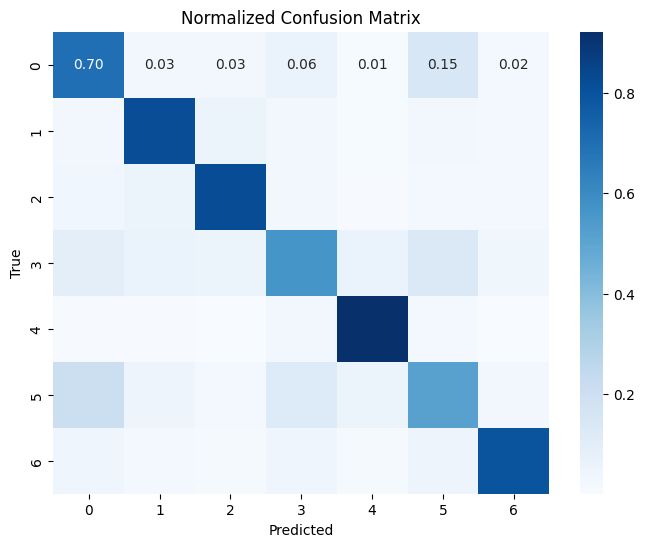

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_norm = confusion_matrix(y.iloc[te], yp, normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
			xticklabels=range(7),
			yticklabels=range(7))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()


In [18]:
import numpy as np
from scipy.stats import entropy

def class_conditional_entropy(y_true, y_pred, cls):
	mask = y_true == cls
	p = np.bincount(y_pred[mask], minlength=7)
	return entropy(p / p.sum(), base=2)

for c in range(7):
	print(f"Class {c} conditional entropy:",
		  class_conditional_entropy(y.iloc[te].values, yp, c))


Class 0 conditional entropy: 1.5105383188262096
Class 1 conditional entropy: 1.1257464795288874
Class 2 conditional entropy: 1.1018113078807104
Class 3 conditional entropy: 2.065541051280167
Class 4 conditional entropy: 0.5550792332306385
Class 5 conditional entropy: 2.0622832773317095
Class 6 conditional entropy: 1.2317233348181504


In [19]:
probs = model.predict_proba(X.iloc[te])

top2 = np.argsort(probs, axis=1)[:, -2:]

almost_correct = np.mean([
	y.iloc[te].values[i] in top2[i]
	for i in range(len(top2))
])

print("Top-2 accuracy:", almost_correct)


Top-2 accuracy: 0.8791875


In [20]:
import numpy as np

probs = model.predict_proba(X.iloc[te])
y_true = y.iloc[te].values
y_pred = probs.argmax(axis=1)

for cls in [0, 3, 5]:
	mask = y_true == cls
	print(f"\nClass {cls}")
	print("Mean max prob:", probs[mask].max(axis=1).mean())
	print("Median max prob:", np.median(probs[mask].max(axis=1)))



Class 0
Mean max prob: 0.6658682094492533
Median max prob: 0.6501967041838417

Class 3
Mean max prob: 0.6465924590515316
Median max prob: 0.6318691658822648

Class 5
Mean max prob: 0.6478120360550049
Median max prob: 0.623838843475713


In [21]:
import numpy as np

probs = model.predict_proba(X.iloc[te])
y_true = y.iloc[te].values
y_pred = probs.argmax(axis=1)

for cls in [0, 3, 5]:
	mask = y_true == cls
	print(f"\nClass {cls}")
	print("Mean max prob:", probs[mask].max(axis=1).mean())
	print("Median max prob:", np.median(probs[mask].max(axis=1)))



Class 0
Mean max prob: 0.6658682094492533
Median max prob: 0.6501967041838417

Class 3
Mean max prob: 0.6465924590515316
Median max prob: 0.6318691658822648

Class 5
Mean max prob: 0.6478120360550049
Median max prob: 0.623838843475713


In [23]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(stop_words="english", min_df=10)
X_counts = vec.fit_transform(df["article"])

def top_terms(label, k=20):
	idx = (df["label"] == label).values  # <-- FIX QUI
	mean_counts = X_counts[idx].mean(axis=0).A1
	top_idx = mean_counts.argsort()[-k:]
	return set(vec.get_feature_names_out()[top_idx])


terms_general = top_terms(5)
terms_ent = top_terms(3)

print("Overlap General–Entertainment:",
	  len(terms_general & terms_ent),
	  terms_general & terms_ent)


Overlap General–Entertainment: 11 {'com', 'img', 'http', 'src', 'rss', '39', 'reuters', 'said', 'new', 'border', 'href'}


In [24]:
vec_t = CountVectorizer(stop_words="english", min_df=5)
Xt = vec_t.fit_transform(df["title"])

def title_entropy(label):
	mask = df["label"] == label
	pred = model.predict_proba(X.iloc[te][mask])
	return np.mean(-np.sum(pred * np.log(pred + 1e-9), axis=1))

for c in [0,3,5]:
	print(c, title_entropy(c))


C:\Users\msist\AppData\Local\Temp\ipykernel_40876\594156163.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pred = model.predict_proba(X.iloc[te][mask])


0 0.9084726611132439


C:\Users\msist\AppData\Local\Temp\ipykernel_40876\594156163.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pred = model.predict_proba(X.iloc[te][mask])


3 0.9927718914432073


C:\Users\msist\AppData\Local\Temp\ipykernel_40876\594156163.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pred = model.predict_proba(X.iloc[te][mask])


5 0.9470288496444054


In [25]:
max_probs = probs.max(axis=1)

for tau in [0.35, 0.40, 0.45]:
	mask = max_probs >= tau
	print(f"τ={tau} | Coverage={mask.mean():.2f}")


τ=0.35 | Coverage=0.94
τ=0.4 | Coverage=0.89
τ=0.45 | Coverage=0.83


In [26]:
y_pruned = y_pred.copy()
ambiguous = max_probs < 0.40

# fallback: assegna General
y_pruned[ambiguous] = 5


In [27]:
from sklearn.metrics import f1_score
print("F1 confident only:",
	  f1_score(y_true[~ambiguous], y_pruned[~ambiguous], average="macro"))


F1 confident only: 0.7454819953943034


General and Entertainment articles share substantial editorial boilerplate, leading to high lexical overlap and conditional entropy. A confidence-based analysis shows that the classifier achieves high performance when sufficient evidence is available (macro-F1 ≈ 0.75), while most errors arise from a small subset of intrinsically ambiguous instances

In [28]:
import re
import pandas as pd
import numpy as np
from urllib.parse import urlparse

from bs4 import BeautifulSoup

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, confusion_matrix, classification_report

# =========================
# HTML -> TEXT + URL TOKENS (lossless)
# =========================
BAD_STRUCT_TOKENS = {
	"href","src","img","border","http","https","www","html","px","amp","quot","nbsp","rss"
}

def normalize_url(u: str):
	try:
		p = urlparse(u)
		domain = (p.netloc or "").lower()
		path = (p.path or "").lower()
		# tokenizza path in pezzi "semantici"
		path_tokens = [t for t in re.split(r"[^a-z0-9]+", path) if len(t) >= 3]
		ext = ""
		m = re.search(r"\.([a-z0-9]{2,5})$", path)
		if m:
			ext = m.group(1)
		return domain, path_tokens, ext
	except Exception:
		return "", [], ""

def html_to_text_keep_urls(html: str) -> str:
	if not isinstance(html, str):
		html = "" if html is None else str(html)

	soup = BeautifulSoup(html, "html.parser")

	# Trasforma <a href=...>anchor</a> in token URL + anchor text
	for a in soup.find_all("a"):
		href = a.get("href", "") or ""
		anchor = a.get_text(" ", strip=True) or ""
		domain, path_tokens, ext = normalize_url(href)

		url_feats = []
		if domain:
			url_feats.append(f"URL_DOMAIN_{domain}")
		for t in path_tokens[:12]:
			url_feats.append(f"URL_PATH_{t}")
		if ext:
			url_feats.append(f"URL_EXT_{ext}")

		repl = " ".join(url_feats + ([anchor] if anchor else []))
		a.replace_with(" " + repl + " ")

	# Per <img alt="..."> usa alt come testo + eventuale src normalizzato
	for img in soup.find_all("img"):
		alt = img.get("alt", "") or ""
		src = img.get("src", "") or ""
		domain, path_tokens, ext = normalize_url(src)

		img_feats = []
		if domain:
			img_feats.append(f"IMG_DOMAIN_{domain}")
		for t in path_tokens[:8]:
			img_feats.append(f"IMG_PATH_{t}")
		if ext:
			img_feats.append(f"IMG_EXT_{ext}")

		repl = " ".join(img_feats + ([alt] if alt else []))
		img.replace_with(" " + repl + " ")

	# Testo finale
	text = soup.get_text(" ", strip=True).lower()

	# pulizia minima: toglie token strutturali, mantiene URL_* e IMG_*
	toks = re.split(r"\s+", text)
	toks = [t for t in toks if t and (t not in BAD_STRUCT_TOKENS)]
	return " ".join(toks)

def preprocess_article(X: pd.Series) -> pd.Series:
	return X.fillna("").astype(str).map(html_to_text_keep_urls)

def get_col(df: pd.DataFrame, col: str) -> pd.Series:
	return df[col].fillna("").astype(str)

# =========================
# LOAD
# =========================
df = pd.read_csv("../data/processed/v3/development_v3.csv")

y = df["label"].values
X_df = df[["title","article","source"]].copy()

# =========================
# PIPELINE (Title + Article(word) + Article(char) + Source tokens)
# =========================
title_pipe = Pipeline([
	("sel", FunctionTransformer(lambda d: get_col(d, "title"), validate=False)),
	("tfidf", TfidfVectorizer(
		ngram_range=(1,2),
		min_df=2,
		max_df=0.9,
		sublinear_tf=True,
		max_features=250_000
	))
])

article_word_pipe = Pipeline([
	("sel", FunctionTransformer(lambda d: preprocess_article(get_col(d, "article")), validate=False)),
	("tfidf", TfidfVectorizer(
		ngram_range=(1,2),
		min_df=2,
		max_df=0.9,
		sublinear_tf=True,
		max_features=350_000
	))
])

article_char_pipe = Pipeline([
	("sel", FunctionTransformer(lambda d: preprocess_article(get_col(d, "article")), validate=False)),
	("tfidf", TfidfVectorizer(
		analyzer="char_wb",
		ngram_range=(3,5),
		min_df=3,
		max_df=0.9,
		sublinear_tf=True,
		max_features=300_000
	))
])

source_pipe = Pipeline([
	("sel", FunctionTransformer(lambda d: get_col(d, "source"), validate=False)),
	("tfidf", TfidfVectorizer(
		analyzer="word",
		ngram_range=(1,2),
		min_df=2,
		max_features=50_000
	))
])

model = Pipeline([
	("feats", FeatureUnion([
		("title", title_pipe),
		("art_w", article_word_pipe),
		("art_c", article_char_pipe),
		("source", source_pipe),
	])),
	("clf", LogisticRegression(
		C=2.0,
		max_iter=2000,
		n_jobs=-1,
		class_weight="balanced"
	))
])

# =========================
# 1 FOLD EVAL
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for tr, te in skf.split(X_df, y):
	model.fit(X_df.iloc[tr], y[tr])
	yp = model.predict(X_df.iloc[te])

	print("Macro F1:", f1_score(y[te], yp, average="macro"))
	print("Macro Recall:", recall_score(y[te], yp, average="macro"))
	print("Confusion Matrix:\n", confusion_matrix(y[te], yp))
	print("\nReport:\n", classification_report(y[te], yp, digits=3))
	break


C:\Users\msist\AppData\Local\Temp\ipykernel_40876\887347601.py:41: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(html, "html.parser")
C:\Users\msist\AppData\Local\Temp\ipykernel_40876\887347601.py:41: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(html, "html.parser")
C:\Users\msist\AppData\Local\Temp\ipykernel_40876\887347601.py:41: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(html, "html.parser")
C:\Users\msist\AppData\Local\Temp\ipykernel_40876\887347601.py:41: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the file

Macro F1: 0.70882815850015
Macro Recall: 0.7244537444014683
Confusion Matrix:
 [[3410  144  117  261   41  653   82]
 [  81 1696  110   88   18   83   41]
 [  74  129 1858   67    8   50   46]
 [ 232  105  112 1099  120  261   67]
 [  22    8    3   67 1556   53    6]
 [ 594  127   57  308  121 1327   77]
 [  42   17   15   33   11   39  464]]

Report:
               precision    recall  f1-score   support

           0      0.765     0.724     0.744      4708
           1      0.762     0.801     0.781      2117
           2      0.818     0.832     0.825      2232
           3      0.572     0.551     0.561      1996
           4      0.830     0.907     0.867      1715
           5      0.538     0.508     0.523      2611
           6      0.593     0.747     0.661       621

    accuracy                          0.713     16000
   macro avg      0.697     0.724     0.709     16000
weighted avg      0.711     0.713     0.711     16000

